KNN

In [ ]:
from sklearn.datasets import load_iris
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
iris = load_iris()
X = iris.data
y = iris.target
for k in range(1, 21):
    model = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(model, X, y, cv=5)

    print(f"K = {k}, Mean Accuracy = {scores.mean():.4f}")

K = 1, Mean Accuracy = 0.9600
K = 2, Mean Accuracy = 0.9467
K = 3, Mean Accuracy = 0.9667
K = 4, Mean Accuracy = 0.9733
K = 5, Mean Accuracy = 0.9733
K = 6, Mean Accuracy = 0.9800
K = 7, Mean Accuracy = 0.9800
K = 8, Mean Accuracy = 0.9667
K = 9, Mean Accuracy = 0.9733
K = 10, Mean Accuracy = 0.9800
K = 11, Mean Accuracy = 0.9800
K = 12, Mean Accuracy = 0.9800
K = 13, Mean Accuracy = 0.9733
K = 14, Mean Accuracy = 0.9667
K = 15, Mean Accuracy = 0.9667
K = 16, Mean Accuracy = 0.9667
K = 17, Mean Accuracy = 0.9667
K = 18, Mean Accuracy = 0.9667
K = 19, Mean Accuracy = 0.9667
K = 20, Mean Accuracy = 0.9600


In [ ]:
import numpy as np
from collections import Counter # a a a a b b. c c c c c  a:4 b:2 c:5
class KNNClassifier:
  def __init__(self, k=3):
    self.k = k
  def fit(self, X, y):
    self.X_train = np.array(X)
    self.y_train = np.array(y)
  def _euclidean(self, a, b):
    return np.sqrt(np.sum((a - b) ** 2))
  def predict_one(self, x):
    dists = []
    for xt in self.X_train:
      dists.append(
      self._euclidean(x, xt)
      )
    k_idx = np.argsort(dists)[:self.k]


    k_labels = [self.y_train[i] for i in k_idx]


    return Counter(k_labels).most_common(1)[0][0]
  def predict(self, X):
    return [self.predict_one(x) for x in X]

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

iris = load_iris()
X, y = iris.data, iris.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
k_range = range(1, 33)
cv_scores = [
    cross_val_score(KNeighborsClassifier(n_neighbors=k), X_train, y_train, cv=5).mean()
    for k in k_range
]
best_k = list(k_range)[cv_scores.index(max(cv_scores))]
print(f'Best K={best_k} CV Acc={max(cv_scores):.4f}')
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train, y_train)

Best K=3 CV Acc=0.9500


KNeighborsClassifier(n_neighbors=3)

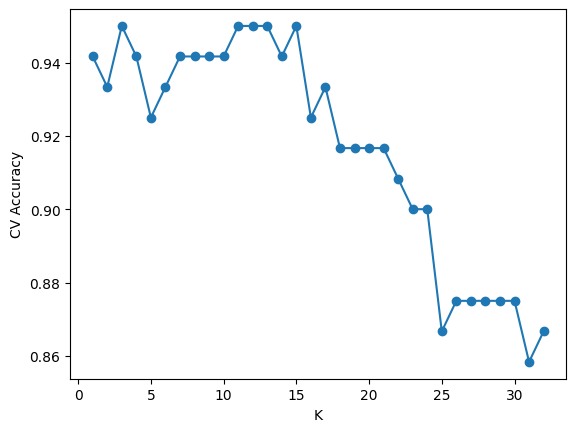

In [ ]:
import matplotlib.pyplot as plt

plt.plot(k_range, cv_scores, marker='o')
plt.xlabel("K")
plt.ylabel("CV Accuracy")
plt.show()

In [ ]:
from sklearn.naive_bayes import MultinomialNB, GaussianNB
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
emails = [
'Win a free iPhone now click here',
'Congratulations you won a lottery prize',
'FREE cash prize claim within 24 hours',
'Limited offer buy now get 50 percent off',
'Meeting at 3pm tomorrow please confirm',
'Quarterly report attached for review',
'Can you send me the project files thanks',
'Team lunch tomorrow noon at cafeteria',
'Urgent your account has been suspended',
'Hi please review the attached document',]
labels = [1,1,1,1,0,0,0,0,1,0]
X_train,X_test,y_train,y_test = train_test_split(
emails, labels, test_size=0.3, random_state=42)
pipe = Pipeline([
('tfidf', TfidfVectorizer(lowercase=True, stop_words='english')),
('nb', MultinomialNB(alpha=1.0)),
])
pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)
print(classification_report(y_test, y_pred, target_names=['Ham','Spam']))

              precision    recall  f1-score   support

         Ham       0.50      1.00      0.67         1
        Spam       1.00      0.50      0.67         2

    accuracy                           0.67         3
   macro avg       0.75      0.75      0.67         3
weighted avg       0.83      0.67      0.67         3



In [ ]:
nb_model = pipe.named_steps['nb']
vectorizer = pipe.named_steps['tfidf']
feature_names = vectorizer.get_feature_names_out()
import numpy as np

In [ ]:
spam_log_probs = nb_model.feature_log_prob_[1]
top_spam_idx = np.argsort(spam_log_probs)[-10:][::-1]
print('Top spam words:', [feature_names[i] for i in top_spam_idx])

Top spam words: ['free', 'win', 'iphone', 'click', 'percent', 'offer', 'buy', 'limited', '50', 'cash']


In [ ]:
new = ['  your       its a new job its been great well working this is example for spuerwhjhfv']
for email, pred, prob in zip(new, pipe.predict(new), pipe.predict_proba(new)):
  print(f'[{"SPAM" if pred==1 else "HAM"}] conf={prob[pred]*100:.1f}% {email}')

[HAM] conf=57.1%   your       its a new job its been great well working this is example for spuerwhjhfv
